In [1]:
import cmdstanpy
cmdstanpy.install_cmdstan()

/Users/aayushmishra/miniconda3/envs/sbi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CmdStan install directory: /Users/aayushmishra/.cmdstan
CmdStan version 2.36.0 already installed
Test model compilation


True

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel
import time
from tqdm import trange
from scipy.stats import beta

## Exercise 1

1.  Write a Stan program for Bayesian linear regression on data $(x_i, y_i)$, $i=1,\dots,N$, with the following model:  
   $$
     \begin{aligned}
       y_i &\sim \mathcal{N}(\alpha + \beta\,x_i,\;\sigma),\\
       \alpha &\sim \mathcal{N}(0,10),\quad
       \beta \sim \mathcal{N}(0,10),\quad
       \sigma \sim \mathrm{Half\!-\!Cauchy}(0,5).
     \end{aligned}
   $$

2. Simulate $N=100$ observations from the model above using true parameter values $\alpha=1.0$, $\beta=2.5$, and $\sigma=1.0$.

3. Compile the Stan model using a programming language of your choice. Run Hamiltonian Monte Carlo with 4 chains, 1000 warmup + 1000 sampling iterations. Report posterior means and 95% credible intervals for $\alpha$, $\beta$, and $\sigma$.

4. Using the same compiled model, run variational inference (`variational()`) in Stan (e.g. 20,000 iterations, 1000 output samples). Report the variational posterior means and standard deviations for $\alpha$, $\beta$, and $\sigma$.

5. Plot marginal posterior densities from MCMC and VI side by side for each parameter. Compare their locations, spreads, and computational times.

In [ ]:
np.random.seed(123)

alpha_true = 1.0
beta_true  = 2.5
sigma_true = 1.0

N = 100
x = np.random.normal(0, 1, size=N)
y = np.random.normal(alpha_true + beta_true * x, sigma_true)

In [6]:
model = CmdStanModel(stan_file='./lin_reg.stan')

# MCMC
start = time.time()
mcmc_fit = model.sample(
    data={'N': N, 'x': x, 'y': y},
    chains=4, parallel_chains=4,
    iter_warmup=1000, iter_sampling=1000
)
mcmc_time = time.time() - start

00:34:18 - cmdstanpy - INFO - compiling stan file /Users/aayushmishra/Desktop/Presentations/sbi/simulation-based-inference/lin_reg.stan to exe file /Users/aayushmishra/Desktop/Presentations/sbi/simulation-based-inference/lin_reg
00:34:21 - cmdstanpy - INFO - compiled model executable: /Users/aayushmishra/Desktop/Presentations/sbi/simulation-based-inference/lin_reg
00:34:22 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |██████████| 00:00 Sampling completed
chain 2 |██████████| 00:00 Sampling completed
chain 3 |██████████| 00:00 Sampling completed
chain 4 |██████████| 00:00 Sampling completed


00:34:22 - cmdstanpy - INFO - CmdStan done processing.
00:34:22 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'lin_reg.stan', line 18, column 2 to column 38)
Consider re-running with show_console=True if the above output is unclear!


In [7]:
# Variational Inference
start = time.time()
vi_fit = model.variational(
    data={'N': N, 'x': x, 'y': y},
    iter=20000,
    output_samples=1000
)
vi_time = time.time() - start

00:34:50 - cmdstanpy - WARNING - Argument name `output_samples` is deprecated, please rename to `draws`.
00:34:50 - cmdstanpy - INFO - Chain [1] start processing
00:34:50 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
idata_mcmc = az.from_cmdstanpy(mcmc_fit)

alpha_draws = vi_fit.stan_variable('alpha', mean=False)
beta_draws  = vi_fit.stan_variable('beta',  mean=False)
sigma_draws = vi_fit.stan_variable('sigma', mean=False)

alpha_draws = alpha_draws[np.newaxis, :]
beta_draws  = beta_draws[np.newaxis, :]
sigma_draws = sigma_draws[np.newaxis, :]

idata_vi = az.from_dict(
    posterior={
        'alpha': alpha_draws,
        'beta':  beta_draws,
        'sigma': sigma_draws
    },
    posterior_kwargs={"validate_dims": False}
)

print("\n--- MCMC posterior summary ---")
print(az.summary(idata_mcmc, var_names=['alpha','beta','sigma'], round_to=2))
print(f"  (wall time: {mcmc_time:.1f}s)")

print("\n--- VI posterior summary ---")
print(az.summary(idata_vi, var_names=['alpha','beta','sigma'], round_to=2))
print(f"  (wall time: {vi_time:.1f}s)")

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)



--- MCMC posterior summary ---
       mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  0.98  0.10    0.80     1.18        0.0      0.0   3866.44   2772.41   
beta   2.48  0.09    2.33     2.66        0.0      0.0   3916.62   2846.68   
sigma  0.99  0.07    0.86     1.13        0.0      0.0   3823.16   2901.68   

       r_hat  
alpha    1.0  
beta     1.0  
sigma    1.0  
  (wall time: 0.5s)

--- VI posterior summary ---
       mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  0.94  0.11    0.76     1.15        0.0      0.0   1049.12    968.67   
beta   2.50  0.10    2.31     2.69        0.0      0.0    807.44    937.28   
sigma  0.97  0.07    0.84     1.09        0.0      0.0    980.61    840.60   

       r_hat  
alpha    NaN  
beta     NaN  
sigma    NaN  
  (wall time: 0.1s)


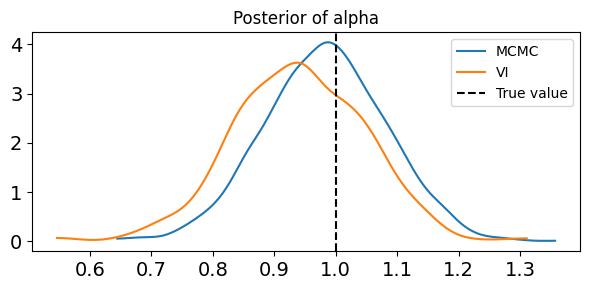

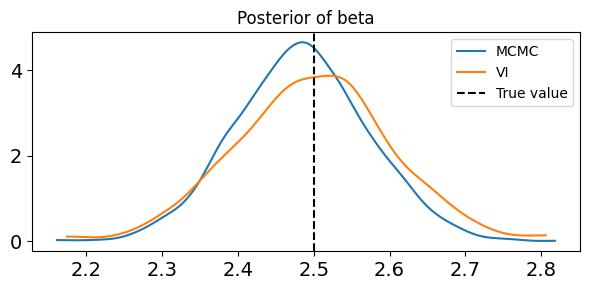

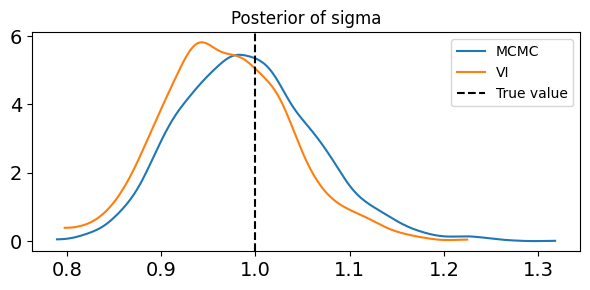

In [ ]:
true_vals = {'alpha': 1.0, 'beta': 2.5, 'sigma': 1.0}

for param in ['alpha','beta','sigma']:
    plt.figure(figsize=(6,3))
    az.plot_kde(
        idata_mcmc.posterior[param].values.flatten(),
        plot_kwargs={'color': 'C0'},
        label='MCMC'
    )
    az.plot_kde(
        idata_vi.posterior[param].values.flatten(),
        plot_kwargs={'color': 'C1'},
        label='VI'
    )
    plt.axvline(
        true_vals[param],
        color='k',     
        linestyle='--',    
        linewidth=1.5,
        label='True value'
    )
    plt.title(f'Posterior of {param}')
    plt.legend()
    plt.tight_layout()

plt.show()

## Exercise 2

Simulate $\displaystyle K$ datasets $\{(x^{(k)}, y^{(k)})\}$ from the prior predictive:
   $$
     \alpha^{(k)} \sim \mathcal{N}(0,10),\quad
     \beta^{(k)} \sim \mathcal{N}(0,10),\quad
     \sigma^{(k)} \sim \mathrm{Half\text{-}Cauchy}(0,5).
   $$
   $$
     x_i \sim \mathcal{N}(0,1)
     \quad\text{independently for }i=1,\dots,N.
   $$
   $$
     y_i^{(k)} \sim \mathcal{N}\bigl(\alpha^{(k)} + \beta^{(k)} x_i,\;\sigma^{(k)}\bigr)
     \quad(i=1,\dots,N).
   $$

Repeat this for $k=1,\dots,K$ replicates to get $K$ synthetic datasets $\{(x^{(k)},y^{(k)})\}$.  

1. Fit both MCMC and VI methods to each simulated dataset to get posterior draws.

2. Sort the posterior draws and compute the rank of the true value among the sorted posterior draws for each parameter and each replicate.

3. Aggregate these ranks over $\displaystyle K$. Plot histograms and ECDF of ranks for both MCMC and VI. 

In [ ]:
# Number of SBC replicates and per-dataset size
K = 200       # replicates
N = 100       # data points per replicate
chains = 4
draws_per_chain = 250       # so total draws = chains * draws_per_chain
total_draws = chains * draws_per_chain

# Compile once
model = CmdStanModel(stan_file='./lin_reg.stan')

ranks = {'alpha': [], 'beta': [], 'sigma': []}

for k in trange(K, desc="SBC"):
    # Sample true parameters from the prior
    alpha_true = np.random.normal(0, 10)
    beta_true  = np.random.normal(0, 10)
    sigma_true = np.abs(np.random.standard_cauchy()) * 5  # half-Cauchy

    # Simulate predictors and responses
    x = np.random.normal(0, 1, size=N)
    y = np.random.normal(alpha_true + beta_true * x, sigma_true, size=N)

    # 2. Fit with HMC
    fit = model.sample(
        data={'N': N, 'x': x, 'y': y},
        chains=chains,
        iter_warmup=500,
        iter_sampling=draws_per_chain,
        show_progress=False,
        show_console=False
    )
    idata = az.from_cmdstanpy(fit)
    post = idata.posterior

    # Compute ranks for each parameter
    for name, true_val in zip(['alpha','beta','sigma'],
                              [alpha_true, beta_true, sigma_true]):
        samples = post[name].values.flatten()
        # How many samples are strictly below the true value?
        rank = np.sum(samples < true_val)
        ranks[name].append(rank)

SBC:   0%|          | 0/200 [00:00<?, ?it/s]14:16:47 - cmdstanpy - INFO - CmdStan start processing
14:16:47 - cmdstanpy - INFO - Chain [1] start processing
14:16:47 - cmdstanpy - INFO - Chain [2] start processing
14:16:47 - cmdstanpy - INFO - Chain [3] start processing
14:16:47 - cmdstanpy - INFO - Chain [4] start processing
14:16:47 - cmdstanpy - INFO - Chain [2] done processing
14:16:47 - cmdstanpy - INFO - Chain [3] done processing
14:16:47 - cmdstanpy - INFO - Chain [1] done processing
14:16:47 - cmdstanpy - INFO - Chain [4] done processing
14:16:47 - cmdstanpy - INFO - CmdStan start processing
14:16:47 - cmdstanpy - INFO - Chain [1] start processing
14:16:47 - cmdstanpy - INFO - Chain [2] start processing
14:16:47 - cmdstanpy - INFO - Chain [3] start processing
14:16:47 - cmdstanpy - INFO - Chain [4] start processing
14:16:47 - cmdstanpy - INFO - Chain [1] done processing
14:16:47 - cmdstanpy - INFO - Chain [2] done processing
14:16:47 - cmdstanpy - INFO - Chain [4] done processin

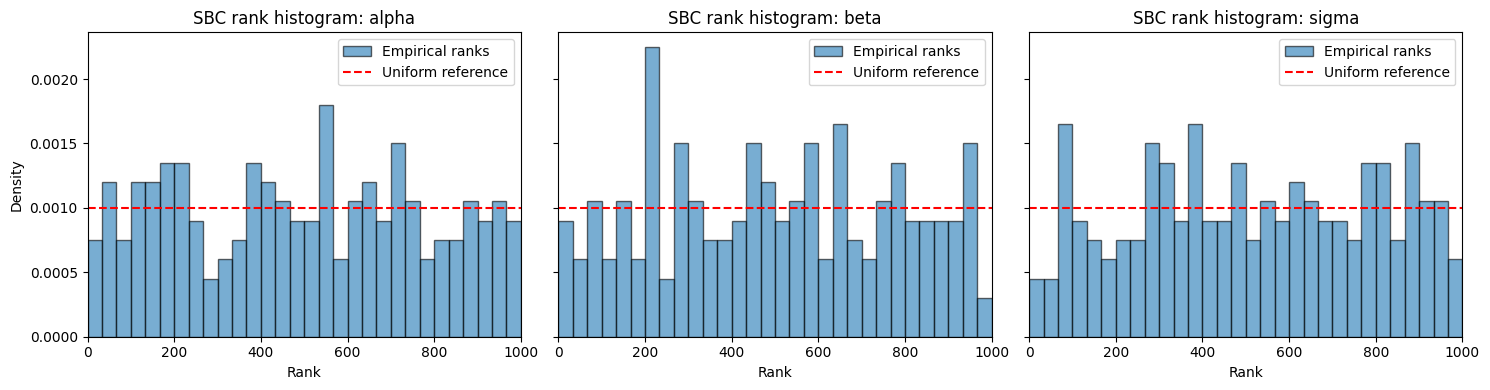

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

nbins = 30  # use a fixed number of bins instead of one per rank
bins = np.linspace(0, total_draws, nbins + 1)

for ax, param in zip(axes, ['alpha', 'beta', 'sigma']):
    ax.hist(
        ranks[param],
        bins=bins,
        density=True,
        edgecolor='k',
        alpha=0.6,                
        label='Empirical ranks'
    )
    ax.hlines(
        1 / (total_draws + 1),
        xmin=0,
        xmax=total_draws,
        color='red',
        linestyle='--',
        label='Uniform reference'
    )
    ax.set_title(f'SBC rank histogram: {param}')
    ax.set_xlabel('Rank')
    ax.set_xlim(0, total_draws)
    if ax is axes[0]:
        ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

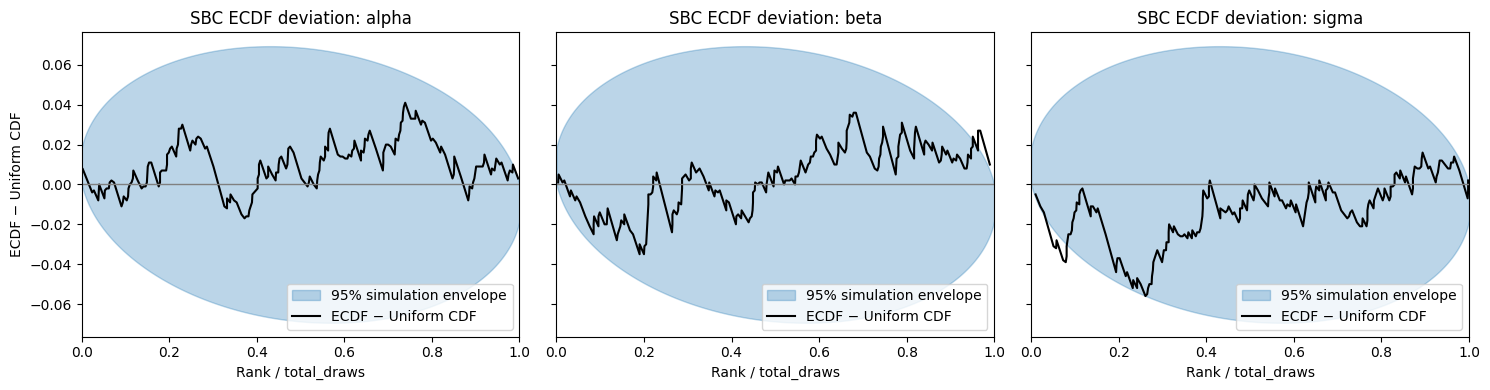

In [ ]:
# build the 95% simulation envelope for ECDF deviations
rs = np.arange(0, total_draws + 1)
lower_env = np.empty_like(rs, dtype=float)
upper_env = np.empty_like(rs, dtype=float)

for i, r in enumerate(rs):
    p = r / total_draws
    # The ECDF at rank r under uniform is Binomial(K, p)/K
    # Its quantiles≈Beta(k+1, K−k+1) so we center to get deviation
    lower_env[i] = beta.ppf(0.025, K * p + 1, K * (1 - p) + 1) - p
    upper_env[i] = beta.ppf(0.975, K * p + 1, K * (1 - p) + 1) - p

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, param in zip(axes, ['alpha', 'beta', 'sigma']):
    # sort observed ranks and compute ECDF deviation
    sorted_r = np.sort(ranks[param])
    ecdf = np.arange(1, K + 1) / K
    deviation = ecdf - (sorted_r / total_draws)

    # draw the 95% envelope as a shaded band
    ax.fill_between(rs/total_draws, lower_env, upper_env,
                    color='C0', alpha=0.3, label='95% simulation envelope')

    # overlay the deviation curve
    ax.plot(sorted_r/total_draws, deviation,
            color='k', lw=1.5, label='ECDF − Uniform CDF')

    ax.axhline(0, color='gray', lw=1)
    ax.set_title(f'SBC ECDF deviation: {param}')
    ax.set_xlabel('Rank / total_draws')
    ax.set_xlim(0, 1)
    if ax is axes[0]:
        ax.set_ylabel('ECDF − Uniform CDF')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()


In [ ]:
# Number of SBC replicates and per-dataset size
K = 200             # replicates
N = 100             # data points per replicate
vi_draws = 1000     # number of VI samples per fit
total_draws = vi_draws  # treat as one “chain”

# Compile once
model = CmdStanModel(stan_file='./lin_reg.stan')

# Storage for ranks
ranks_vi = {'alpha': [], 'beta': [], 'sigma': []}

for k in trange(K, desc="SBC (VI)"):

    alpha_true = np.random.normal(0, 10)
    beta_true  = np.random.normal(0, 10)
    sigma_true = np.abs(np.random.standard_cauchy()) * 5  # half-Cauchy

    x = np.random.normal(0, 1, size=N)
    y = np.random.normal(alpha_true + beta_true * x, sigma_true, size=N)

    # Fit with Variational Inference
    vb = model.variational(
        data={'N': N, 'x': x, 'y': y},
        iter=20000,
        output_samples=vi_draws,
        grad_samples=40,
        elbo_samples=20,
        require_converged=False,
        show_console=False
    )

    alpha_draws = vb.stan_variable('alpha', mean=False)
    beta_draws  = vb.stan_variable('beta',  mean=False)
    sigma_draws = vb.stan_variable('sigma', mean=False)

    ranks_vi['alpha'].append(np.sum(alpha_draws < alpha_true))
    ranks_vi['beta'].append( np.sum(beta_draws  < beta_true))
    ranks_vi['sigma'].append(np.sum(sigma_draws < sigma_true))

SBC (VI):   0%|          | 0/200 [00:00<?, ?it/s]14:19:18 - cmdstanpy - WARNING - Argument name `output_samples` is deprecated, please rename to `draws`.
14:19:18 - cmdstanpy - INFO - Chain [1] start processing
14:19:18 - cmdstanpy - INFO - Chain [1] done processing
SBC (VI):   0%|          | 1/200 [00:00<00:48,  4.07it/s]14:19:18 - cmdstanpy - WARNING - Argument name `output_samples` is deprecated, please rename to `draws`.
14:19:18 - cmdstanpy - INFO - Chain [1] start processing
14:19:19 - cmdstanpy - INFO - Chain [1] done processing
14:19:19 - cmdstanpy - WARNING - Argument name `output_samples` is deprecated, please rename to `draws`.
14:19:19 - cmdstanpy - INFO - Chain [1] start processing
14:19:19 - cmdstanpy - INFO - Chain [1] done processing
SBC (VI):   2%|▏         | 3/200 [00:00<00:37,  5.21it/s]14:19:19 - cmdstanpy - WARNING - Argument name `output_samples` is deprecated, please rename to `draws`.
14:19:19 - cmdstanpy - INFO - Chain [1] start processing
14:19:19 - cmdstanpy 

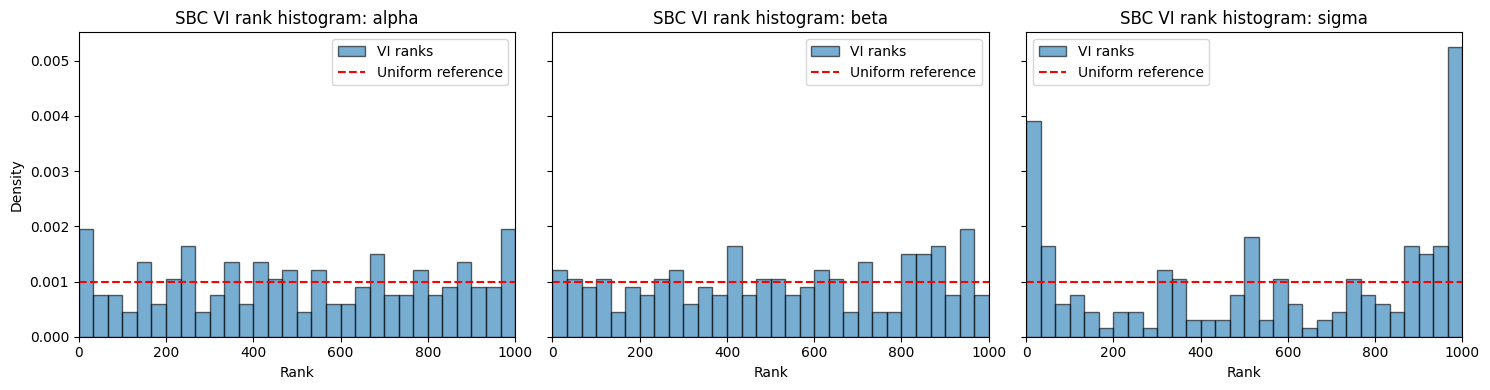

In [ ]:
# 4. Plot histograms of VI ranks
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# same binning strategy as before
nbins = 30
bins = np.linspace(0, total_draws, nbins + 1)

for ax, param in zip(axes, ['alpha', 'beta', 'sigma']):
    ax.hist(
        ranks_vi[param],
        bins=bins,
        density=True,
        edgecolor='k',
        alpha=0.6,
        label='VI ranks'
    )
    ax.hlines(
        1 / (total_draws + 1),
        xmin=0,
        xmax=total_draws,
        color='red',
        linestyle='--',
        label='Uniform reference'
    )
    ax.set_title(f'SBC VI rank histogram: {param}')
    ax.set_xlabel('Rank')
    ax.set_xlim(0, total_draws)
    if ax is axes[0]:
        ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()


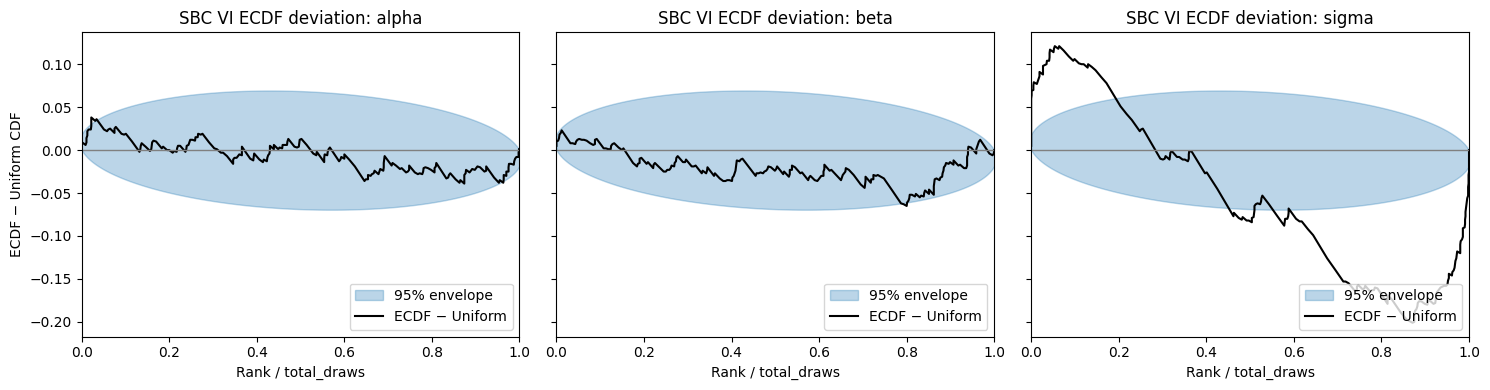

In [ ]:
# Build the 95% simulation envelope
rs = np.arange(0, total_draws + 1)
lower_env = np.empty_like(rs, dtype=float)
upper_env = np.empty_like(rs, dtype=float)

for i, r in enumerate(rs):
    p = r / total_draws
    # ECDF(r) ~ Binomial(K, p)/K ⇒ quantiles via Beta
    lower_env[i] = beta.ppf(0.025, K * p + 1, K * (1 - p) + 1) - p
    upper_env[i] = beta.ppf(0.975, K * p + 1, K * (1 - p) + 1) - p

# Plot ECDF deviations for VI
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, param in zip(axes, ['alpha', 'beta', 'sigma']):
    # sort the VI ranks and compute ECDF minus uniform CDF
    sorted_r = np.sort(ranks_vi[param])
    ecdf_vals = np.arange(1, K + 1) / K
    deviation = ecdf_vals - (sorted_r / total_draws)

    # shaded 95% envelope
    ax.fill_between(rs / total_draws, lower_env, upper_env,
                    color='C0', alpha=0.3, label='95% envelope')

    # the ECDF deviation curve
    ax.plot(sorted_r / total_draws, deviation,
            color='k', lw=1.5, label='ECDF − Uniform')

    ax.axhline(0, color='gray', lw=1)
    ax.set_title(f'SBC VI ECDF deviation: {param}')
    ax.set_xlabel('Rank / total_draws')
    ax.set_xlim(0, 1)
    if ax is axes[0]:
        ax.set_ylabel('ECDF − Uniform CDF')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()